In [1]:
# Bank Marketing pipeline with SMOTE (imblearn)
# Save as a notebook cell or .py and run.
# Requires: numpy, pandas, matplotlib, scikit-learn, joblib, imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
import joblib

# sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_auc_score, precision_recall_curve, auc, precision_score,
                             recall_score, f1_score, roc_curve)
# imblearn imports (SMOTE + pipeline)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# -------------------------
# Config
# -------------------------
CSV_PATH = "bank-additional-full.csv"   # update path if needed
RANDOM_STATE = 1
TEST_SIZE = 0.30
N_JOBS = -1

In [2]:
# -------------------------
# 1) Load dataset
# -------------------------

df = pd.read_csv(CSV_PATH, delimiter=';')
df.rename(columns={'y': 'subscribed_deposit'}, inplace=True)

print("Initial shape:", df.shape)

Initial shape: (41188, 21)


In [3]:
# -------------------------
# 2) Basic cleaning
# -------------------------
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

# pdays: 999 -> never contacted. Create a flag and replace 999 with -1 (or keep as is but flag is useful)
df['pdays_never_contacted'] = (df['pdays'] == 999).astype(int)
df['pdays'] = df['pdays'].replace(999, -1)

# Drop leakage variable 'duration' for pre-call model
if 'duration' in df.columns:
    df.drop(columns=['duration'], inplace=True)
    print("Dropped 'duration' (leakage)")

Duplicates before: 12
Duplicates after: 0
Dropped 'duration' (leakage)


In [4]:
# -------------------------
# 3) Feature engineering
# -------------------------
# age bins
df['age_bin'] = pd.cut(df['age'], bins=[16,25,35,50,65,100], labels=['17-25','26-35','36-50','51-65','66+'])

# month cyclical encoding
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
if 'month' in df.columns:
    df['month_num'] = df['month'].str.lower().map(month_map)
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    df.drop(columns=['month','month_num'], inplace=True)

# ever_contacted
df['ever_contacted'] = ((df['previous'] > 0) | (df['pdays'] >= 0)).astype(int)

In [5]:
# -------------------------
# 4) Prepare X, y
# -------------------------
TARGET = 'subscribed_deposit'
df[TARGET] = df[TARGET].map({'yes':1, 'no':0})
df = df.dropna(subset=[TARGET])  # ensure target not null

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("Features shape:", X.shape)
print("Target distribution (counts):\n", y.value_counts())

Features shape: (41176, 23)
Target distribution (counts):
 subscribed_deposit
0    36537
1     4639
Name: count, dtype: int64


In [6]:
# -------------------------
# 5) Train-test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (28823, 23) Test: (12353, 23)


In [8]:
# -------------------------
# 6) Preprocessing
# -------------------------
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object','category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", cat_features)

numeric_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')

Numeric features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_never_contacted', 'month_sin', 'month_cos', 'ever_contacted']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome', 'age_bin']


In [9]:
# -------------------------
# 7) Pipeline with SMOTE + RandomForest
# Important: SMOTE is inside the pipeline so it runs only on training folds in CV
# -------------------------
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS)
pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', rf)
])

In [10]:
# -------------------------
# 8) RandomizedSearchCV hyperparameter tuning (optimize for F1)
# -------------------------
param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [6, 10, 15, 25, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    # optionally: 'clf__max_features': ['sqrt','log2', 0.4, 0.6]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rs = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=20, scoring='f1',
                        n_jobs=N_JOBS, cv=cv, random_state=RANDOM_STATE, verbose=1)

print("Starting RandomizedSearchCV with SMOTE (this will take time)...")
rs.fit(X_train, y_train)

print("Best params:", rs.best_params_)
print("Best CV F1:", rs.best_score_)

Starting RandomizedSearchCV with SMOTE (this will take time)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 8, 'clf__max_depth': 10}
Best CV F1: 0.4932328570396316



Test metrics:
Accuracy: 0.8735529830810329
Precision: 0.45298672566371684
Recall: 0.5883620689655172
F1: 0.511875
ROC AUC: 0.7956165380497416

Confusion Matrix:
 [[9972  989]
 [ 573  819]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93     10961
           1       0.45      0.59      0.51      1392

    accuracy                           0.87     12353
   macro avg       0.70      0.75      0.72     12353
weighted avg       0.89      0.87      0.88     12353

PR-AUC: 0.4604534034816214


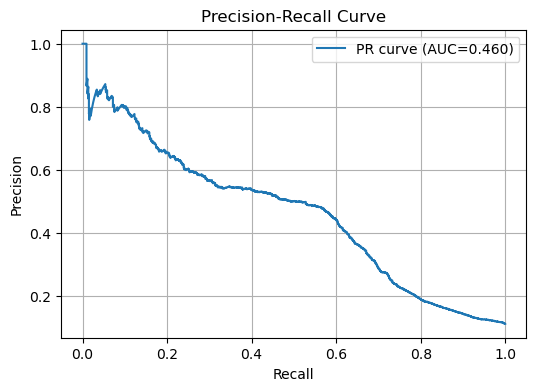

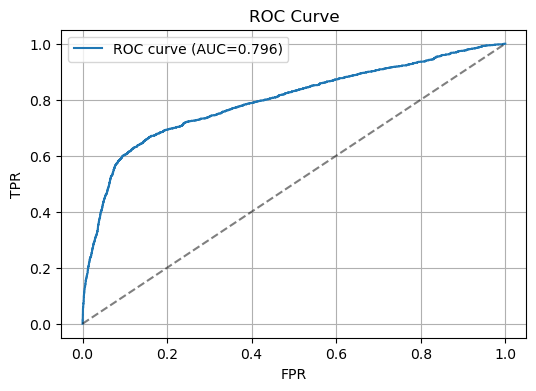

In [11]:
# -------------------------
# 9) Evaluate on test set
# -------------------------
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("\nTest metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# PR-AUC
prec, rec, thr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rec, prec)
print("PR-AUC:", pr_auc)

# Plot Precision-Recall
plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f'PR curve (AUC={pr_auc:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.legend(); plt.grid(True)
plt.show()

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC={roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.grid(True)
plt.show()


Top feature importances:
 nr.employed                    0.118234
euribor3m                      0.117801
emp.var.rate                   0.087856
cons.conf.idx                  0.055345
contact_telephone              0.040982
cons.price.idx                 0.039965
campaign                       0.038030
month_sin                      0.034850
contact_cellular               0.034777
pdays                          0.033756
month_cos                      0.029801
pdays_never_contacted          0.027227
day_of_week_mon                0.021937
default_no                     0.019695
default_unknown                0.019251
day_of_week_thu                0.017683
job_blue-collar                0.017147
poutcome_success               0.016964
day_of_week_fri                0.016276
job_admin.                     0.016256
day_of_week_tue                0.014394
education_university.degree    0.014370
age                            0.011570
loan_no                        0.011499
day_of_week_w

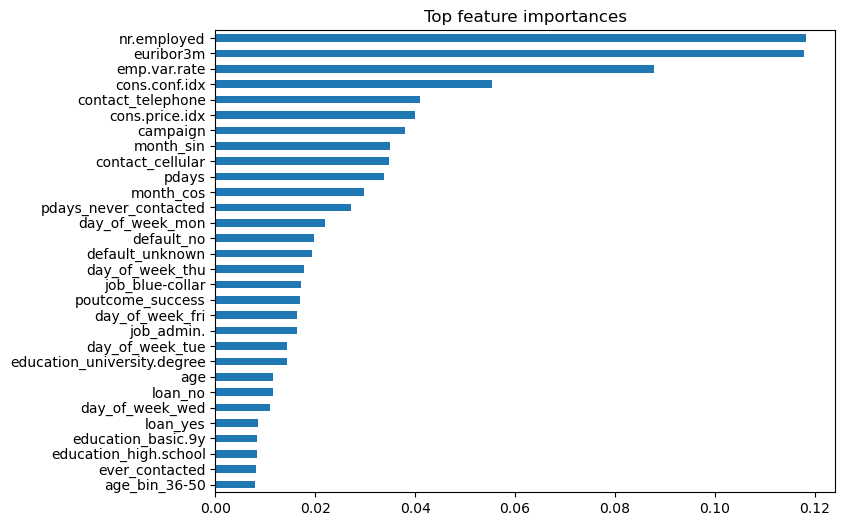

In [12]:
# -------------------------
# 10) Feature importances mapping (approx)
# -------------------------
# Retrieve onehot encoder to expand categorical names
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
num_names = numeric_features
cat_names = []
if hasattr(ohe, 'get_feature_names_out'):
    cat_names = list(ohe.get_feature_names_out(cat_features))
else:
    # fallback: build names from categories_
    for i, col in enumerate(cat_features):
        vals = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].categories_[i]
        cat_names.extend([f"{col}_{v}" for v in vals])

feature_names = num_names + cat_names
importances = best_model.named_steps['clf'].feature_importances_

if len(importances) == len(feature_names):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(30)
    print("\nTop feature importances:\n", fi)
    plt.figure(figsize=(8,6))
    fi.plot(kind='barh'); plt.gca().invert_yaxis(); plt.title('Top feature importances'); plt.show()
else:
    print("Feature name / importance length mismatch (skipping importance mapping)")

In [13]:
# -------------------------
# 11) Save pipeline
# -------------------------
OUT_PATH = "bank_deposit_pipeline_with_smote.joblib"
joblib.dump(rs.best_estimator_, OUT_PATH)
print(f"Saved best pipeline to {OUT_PATH} at {datetime.now().isoformat()}")

Saved best pipeline to bank_deposit_pipeline_with_smote.joblib at 2025-11-24T22:54:29.651258


In [14]:
# -------------------------
# 12) Lift / decile analysis
# -------------------------
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_prob'] = y_prob
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop')

lift = test_df.groupby('decile').agg(count=('y_true','size'),
                                     positives=('y_true','sum'),
                                     avg_prob=('y_prob','mean')).sort_index(ascending=False)

lift['response_rate'] = lift['positives'] / lift['count']
print("\nTop deciles (higher decile => higher predicted probability):\n", lift.head(5))

print("\nSample predictions (first 10 rows):")
print(test_df[['y_true','y_prob']].head(10))

print("\nDone.")


Top deciles (higher decile => higher predicted probability):
         count  positives  avg_prob  response_rate
decile                                           
9        1236        637  0.777906       0.515372
8        1235        265  0.503701       0.214575
7        1235        102  0.350233       0.082591
6        1235         64  0.305001       0.051822
5        1235         60  0.272503       0.048583

Sample predictions (first 10 rows):
       y_true    y_prob
25325       0  0.224527
6644        0  0.178230
6673        0  0.116684
29469       0  0.582259
33697       0  0.325548
18138       0  0.264206
37409       1  0.814824
39850       0  0.686740
6669        0  0.147977
15955       0  0.298678

Done.
